In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import os
import sys
import numpy as np
import matplotlib.pyplot as plt


# Add the parent directory (which contains the fmcg package) to Python path
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import fmcg
from fmcg.pipeline.preprocessing import load_and_preprocess
from fmcg.fitting.inverse_solver import InverseSolver
from fmcg.utils.plotting.plot_utils import plot_magnetic_moments, plot_sensor_signals
from fmcg.analysis.hr import compute_hr
from fmcg.analysis.heartbeat_averaging import find_segments_and_average_heartbeats


logging.basicConfig(level=logging.ERROR, format="%(message)s", force=True)

## Data Loading and Preprocessing

This example demonstrates how to use the forward model-based reconstruction approach to localize fetal cardiac sources from fMCG measurements.

Preprocessed signal: 297.1s at 200 Hz, 24 valid channels


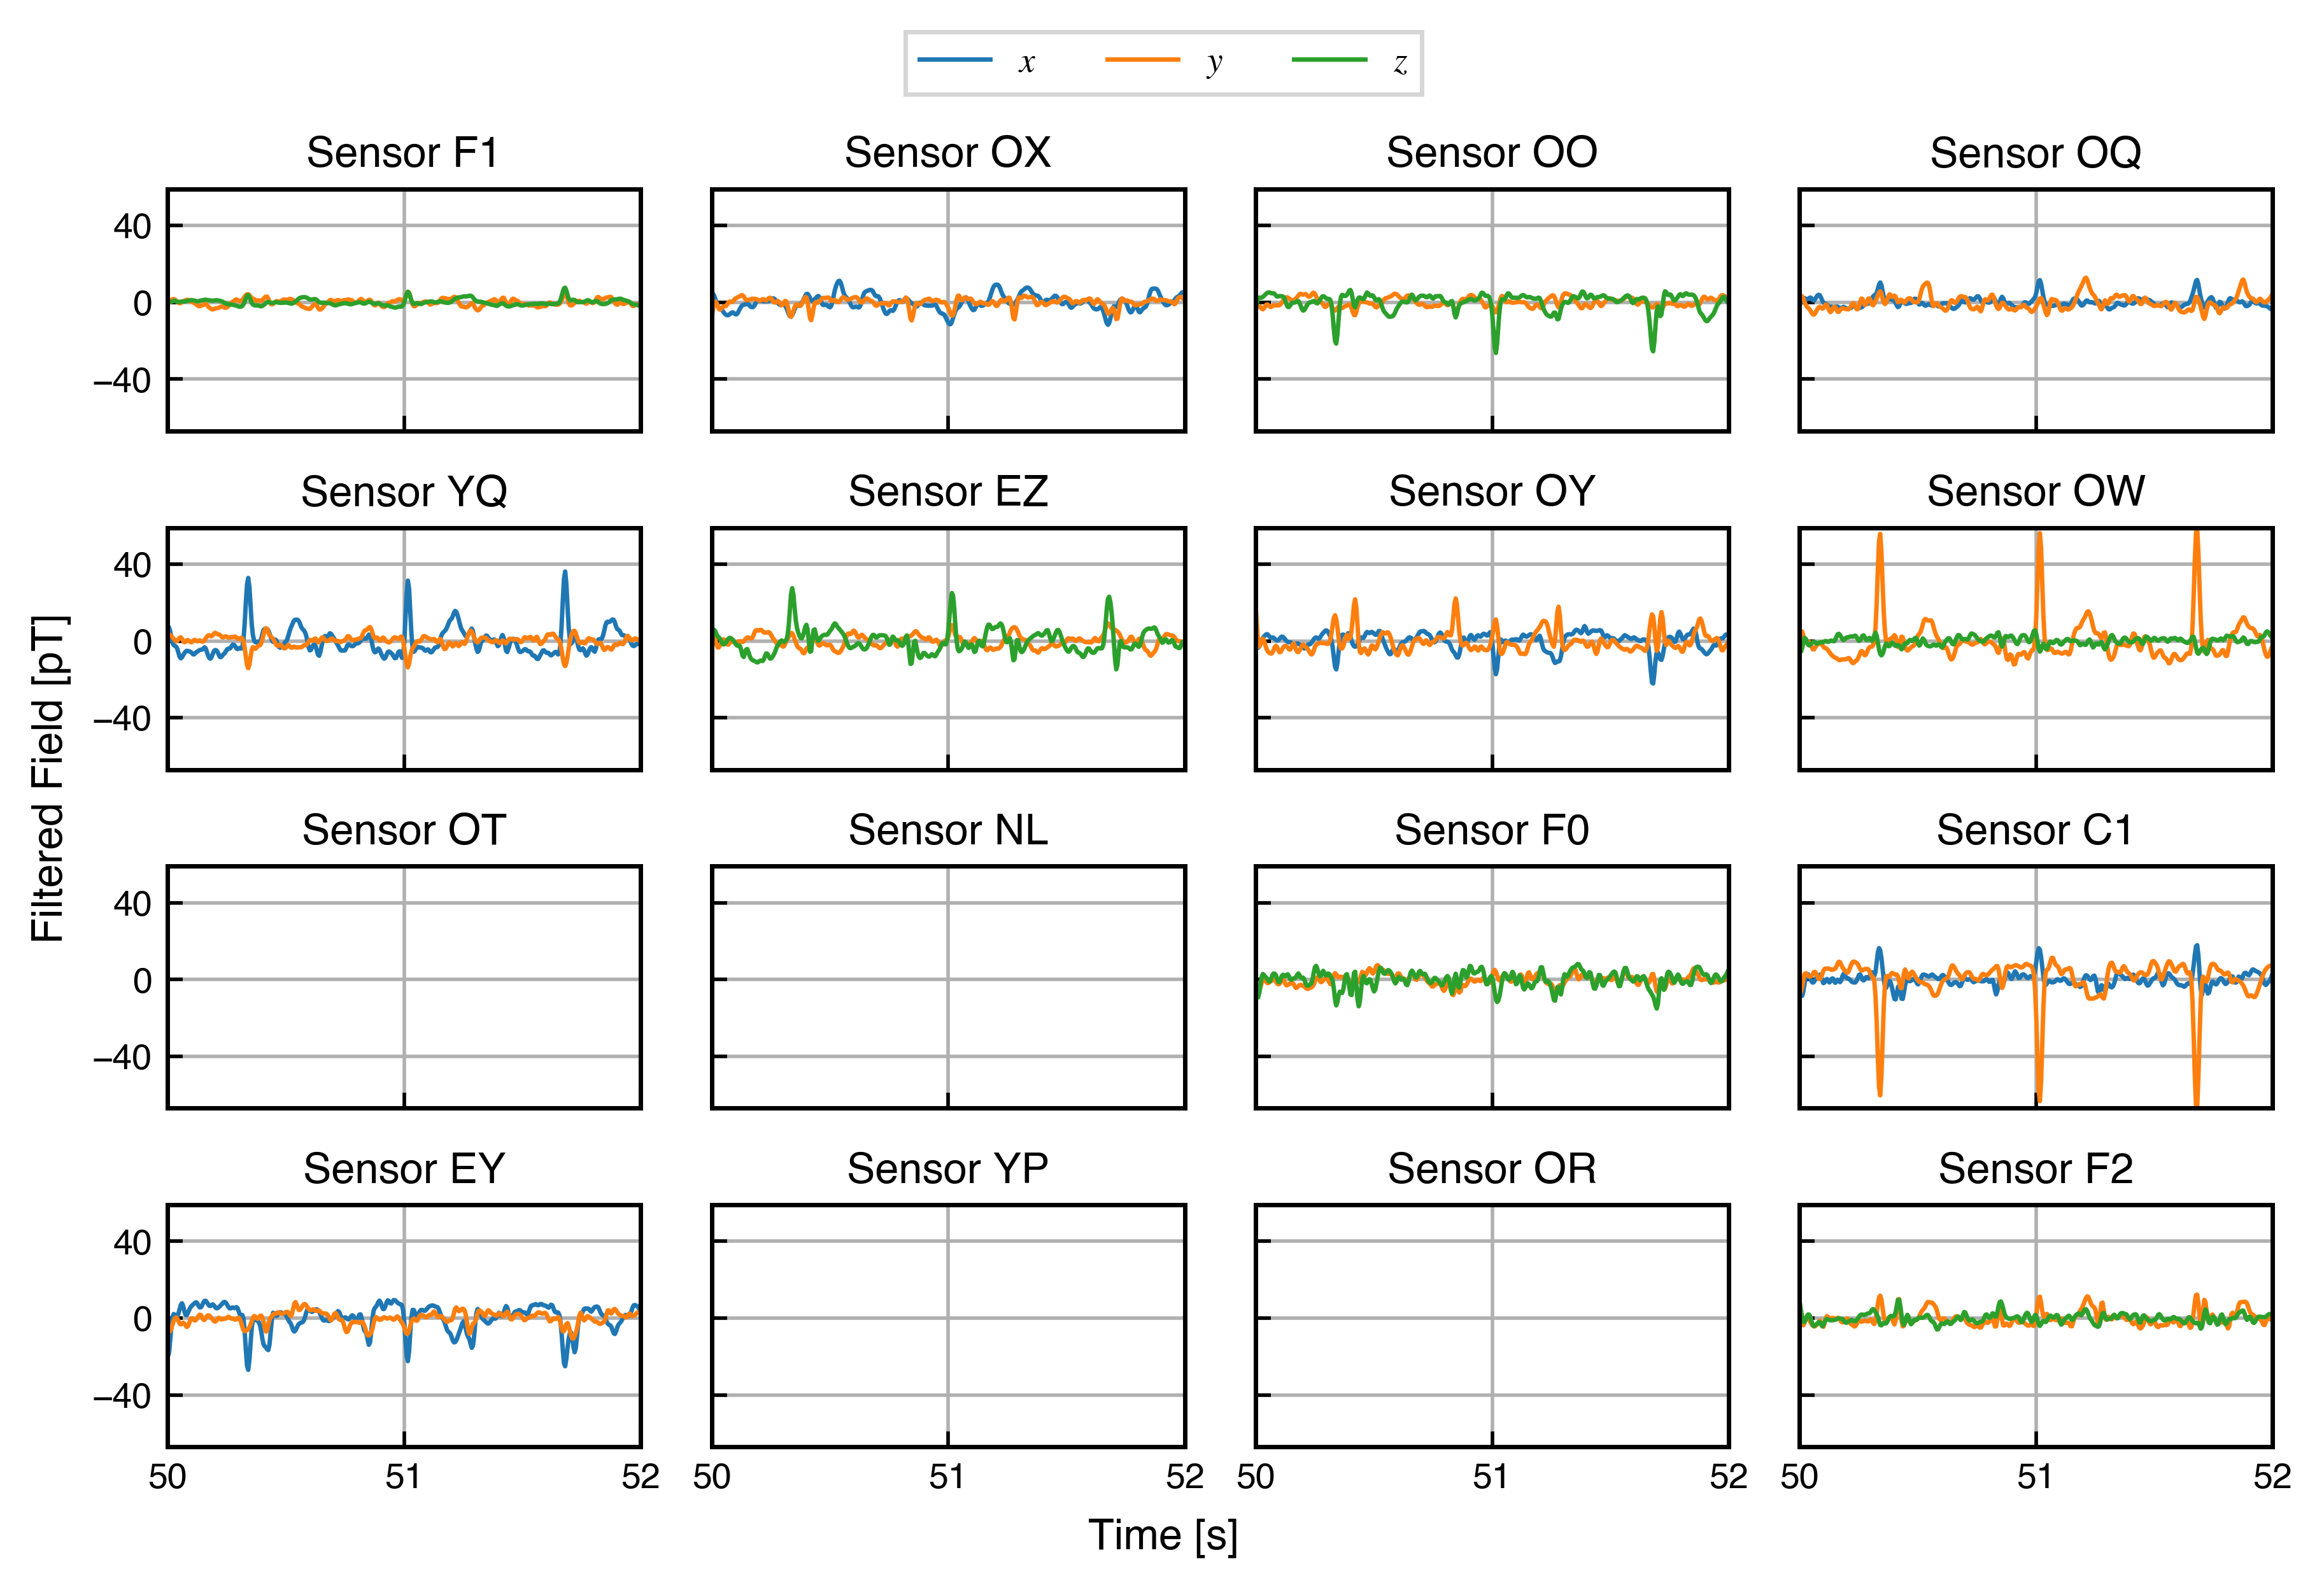

In [3]:

DS_PATH = os.path.dirname(os.path.abspath('.')) + "/data"

field_maps, noise_maps, axis_mask, W_n, fs, time, r_sensors, artifacts_mask, sensor_names = load_and_preprocess(
    ds_path=DS_PATH,
    patient="P097",
    series="S07",
    sig_group_names="R001",
    noise_group_names="R004",
    whitening="PCA",
    downsample_factor=5,  # 1000 → 200 Hz
)

print(f"Preprocessed signal: {field_maps.shape[0]/fs:.1f}s at {fs} Hz, {int(axis_mask.sum())} valid channels")

plot_sensor_signals(
    field_maps,
    time,
    ylabel="Filtered Field [pT]",
    xlim=[50, 52],
    sharey=True,
    sensor_names=sensor_names,
)

## Forward Model Setup

Set up the inverse solver with sensor positions and configuration.

In [4]:
# Define bounds for dipole positions (fetal and maternal)
# Format: [dipole_idx, coordinate_idx] -> (min, max) in meters
r_bnds = np.array([
    [(-0.3, 0.3), (-0.3, -0.005), (-0.3, 0.3)],
    [(-0.3, 0.3), (-0.3, -0.005), (0.1, 0.6)]
])

# Initial dipole positions
r_init = np.array([[[0, -0.02, 0.0], [0, -0.05, 0.2]]])

print(f"Sensor positions shape: {r_sensors.shape}")
print(f"Position bounds shape: {r_bnds.shape}")
print(f"Initial positions shape: {r_init.shape}")

Sensor positions shape: (16, 3)
Position bounds shape: (2, 3, 2)
Initial positions shape: (1, 2, 3)


## Initialize Inverse Solver

Create the inverse solver with optimizer settings.

In [5]:
# Select a time window to fit
t_start = 60  # seconds
t_end = 90  # seconds
window_mask = (time >= t_start) & (time <= t_end)

field_window = field_maps[window_mask, :, :]
time_window = time[window_mask]

print(f"Fitting window: {t_start}-{t_end}s ({field_window.shape[0]} samples)")

Fitting window: 60-90s (6000 samples)


In [29]:
r_basis_args = {"basis": "sigmoid_time_constant", "n_time": time_window.shape[0], "bnds": r_bnds}

# Create inverse solver instance
solver = InverseSolver(
    r_sensors=r_sensors,
    method="lamb",
    num_dipoles=2,  # Fetal + maternal
    axis_mask=axis_mask,
    scaling=dict(m=[1e0, 1e0]),
    basis=dict(r=r_basis_args),
    bnds=dict(r=r_bnds),
    whitening_matrix=W_n,
    device="cuda:0",  # Use "cuda:0" for GPU, "cpu" for CPU
    verbose=True,
)

print(f"Solver initialized with {solver.num_dipoles} dipoles")
print(f"Device: {solver.device}")

Solver initialized with 2 dipoles
Device: cuda:0



Running inverse solver...


Iterations: 100%|██████████| 550/550 [00:08<00:00, 66.18it/s, Best Loss=0.0917]


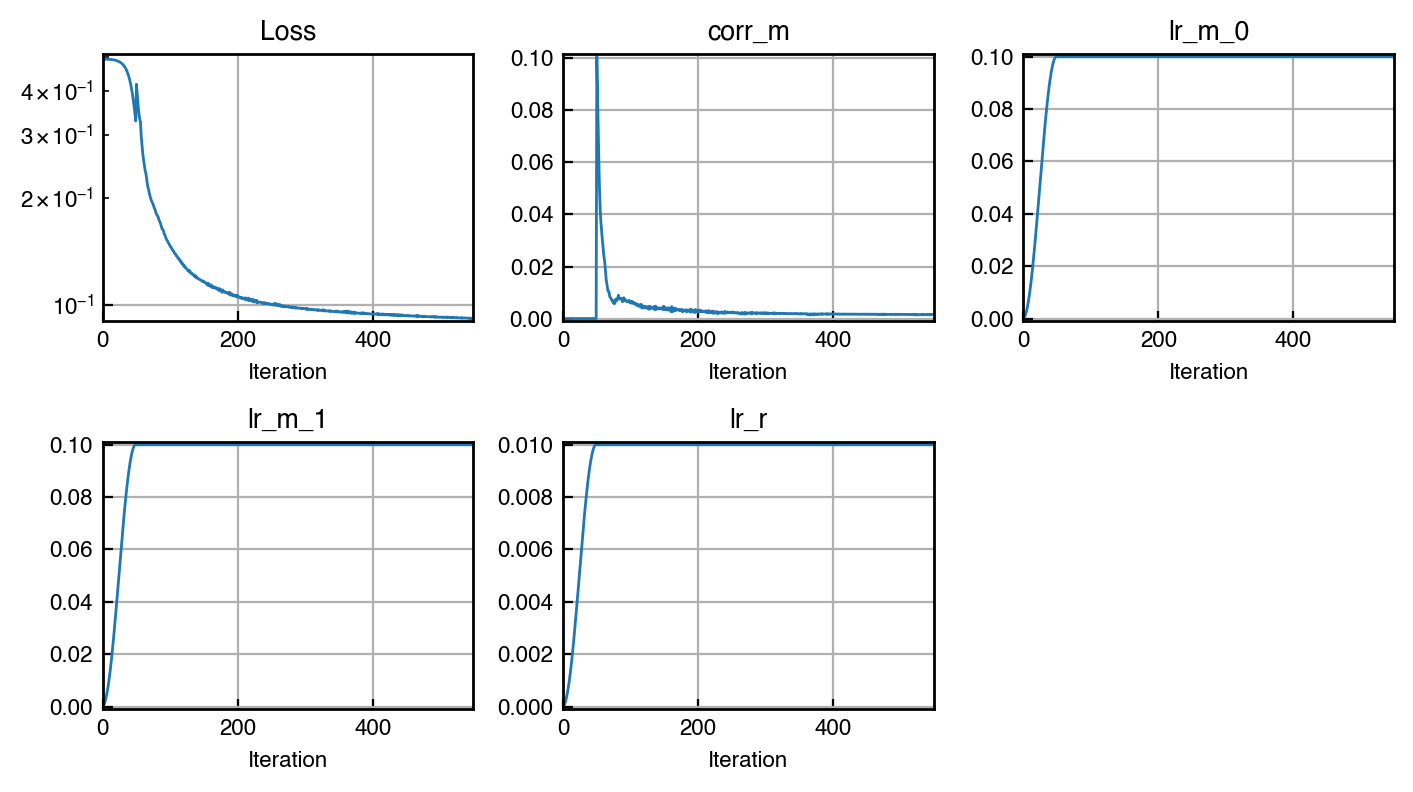


 Fitting complete!
Fitted positions shape: (6000, 2, 3)
Fitted moments shape: (6000, 2, 3)


In [30]:
import torch

# Convert measured field to torch tensor (T x sensors x 3).
field_tensor = torch.tensor(field_window, dtype=torch.float32, device=solver.device)
r_init_repeated = np.repeat(r_init, field_tensor.shape[0], axis=0)
r_init_tensor = torch.tensor(r_init_repeated, dtype=torch.float32, device=solver.device)

# Initialize parameters using pseudo-inverse (regularized)
initial_parameters, field_scaled = solver.initialize_parameters(
    r_init_tensor,
    field_tensor,
    field_scaling=1e0,
    method="pseudo_inv_regularized",
    rcond=1e0,
    determine_scaling=True,
    update_m_scaling=True
)

# Configure solver with learning rates and regularization
config = {
    "lr_groups": [1e-1, 1e-1, 1e-2],  # [lr_m_dipole0, lr_m_dipole1, lr_r]
    "patience_groups": [20], 
    "niter": 500,
    "warmup": 50,
    "early_stopping_patience": 50,
    "early_stopping_threshold": 1e-8,
    "min_iter": 100,
    "corr_m_weight": 5e-1,
}

# Run the solver
print("\nRunning inverse solver...")
m_hat, r_hat = solver.solve_with_config(
    field_scaled,
    initial_parameters,
    config,
    plot=True,
    early_stop=True
)

print("\n Fitting complete!")
print(f"Fitted positions shape: {r_hat.shape}")
print(f"Fitted moments shape: {m_hat.shape}")

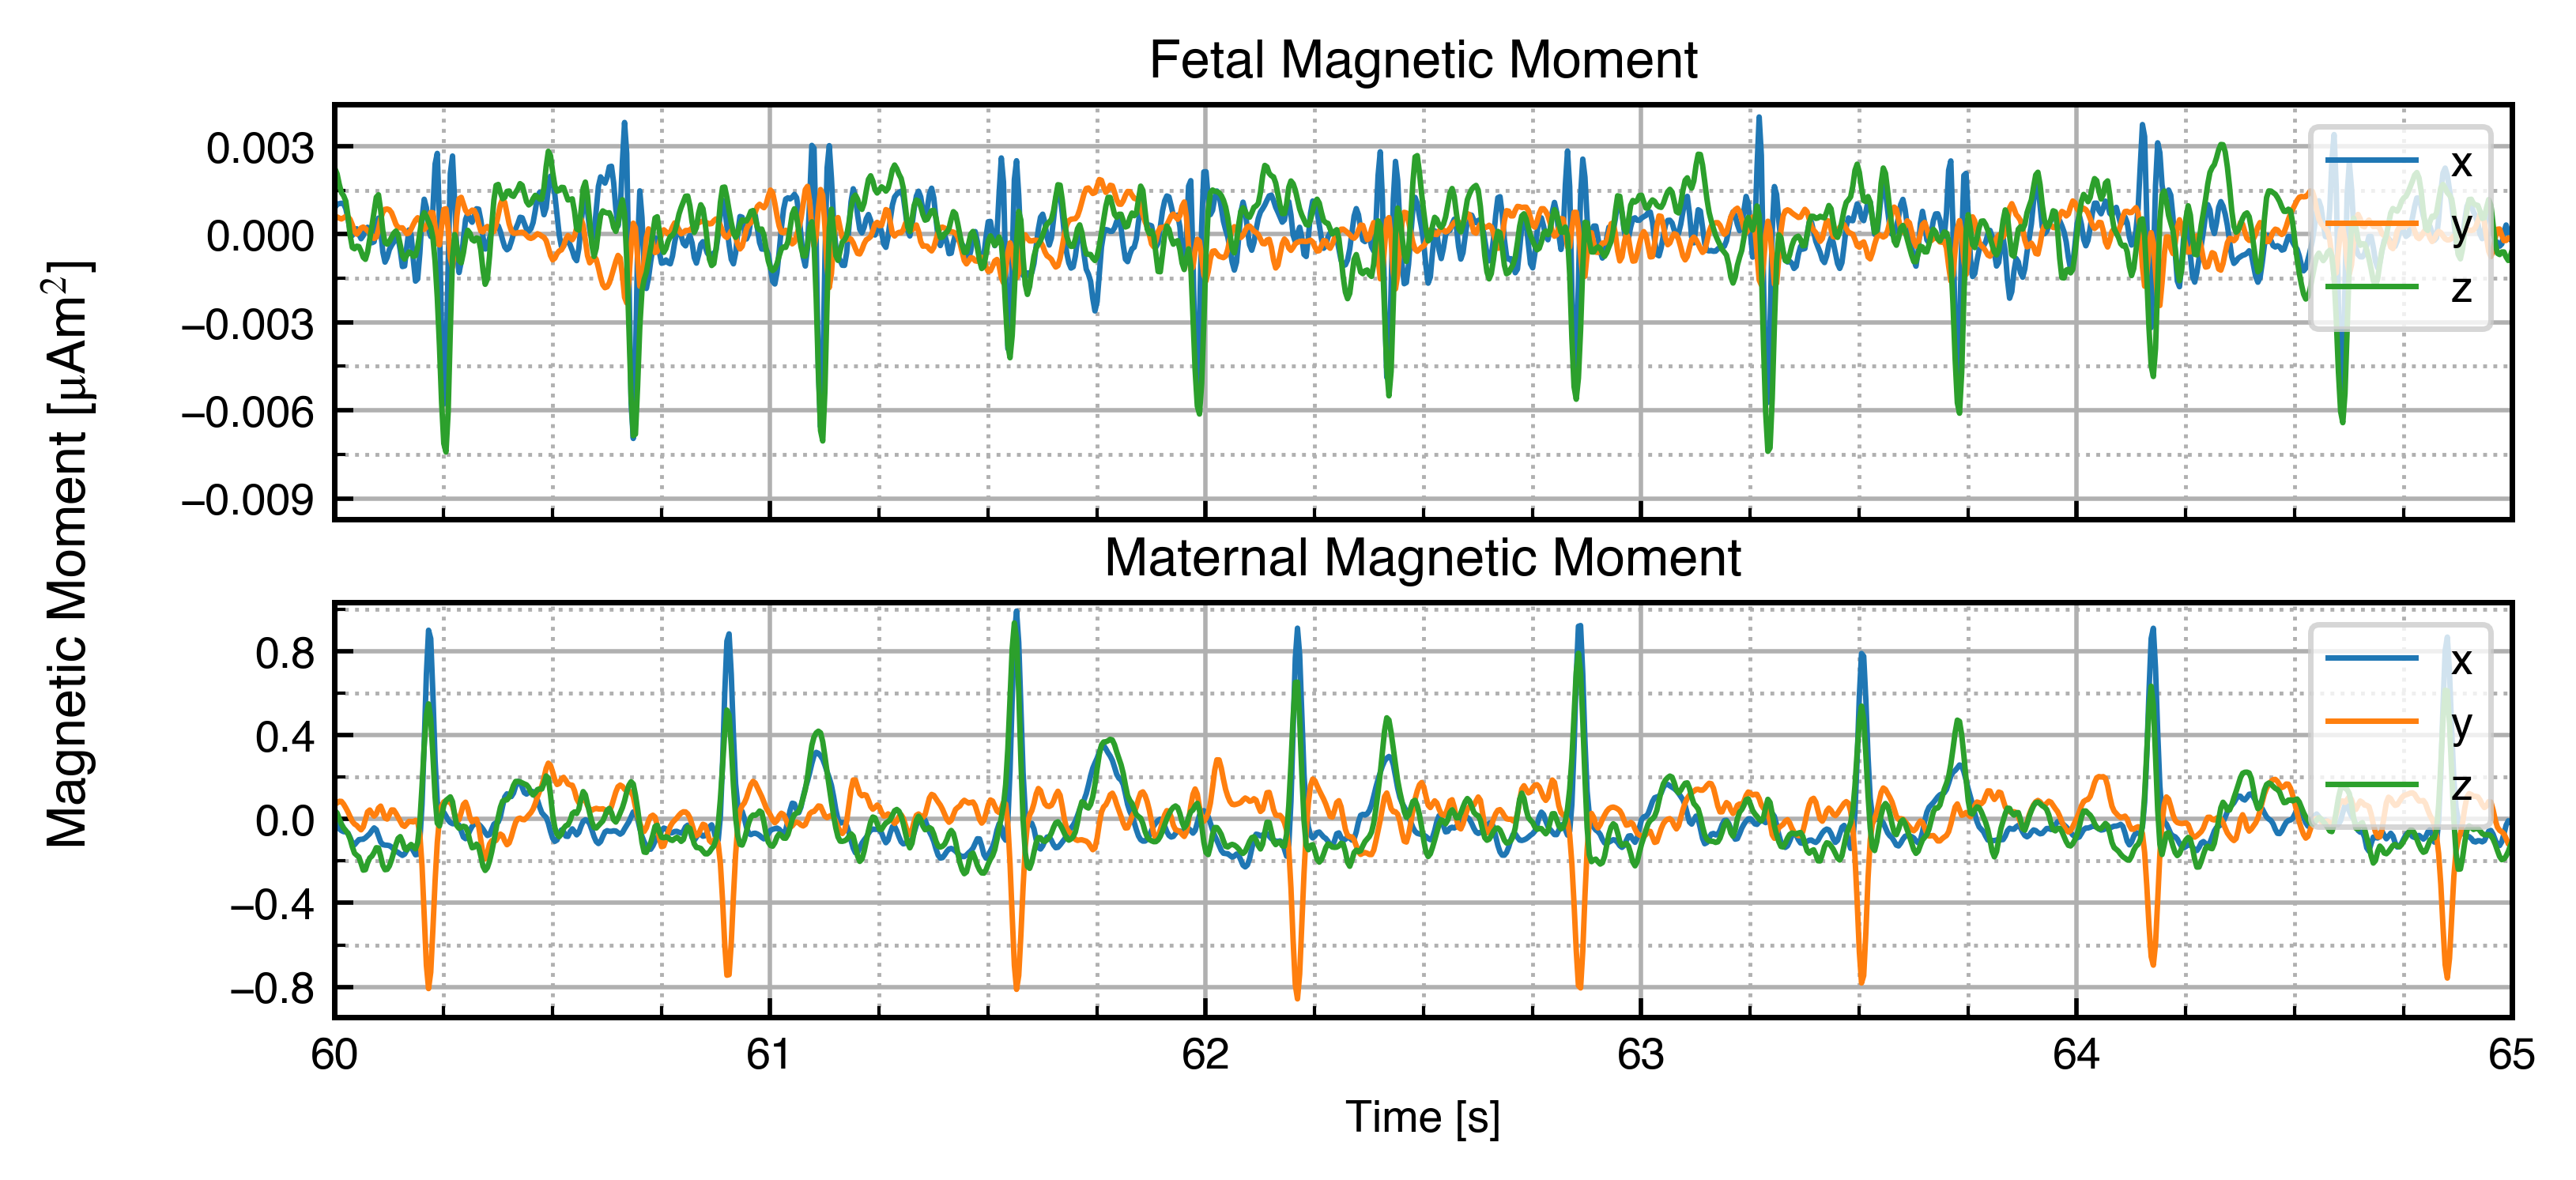

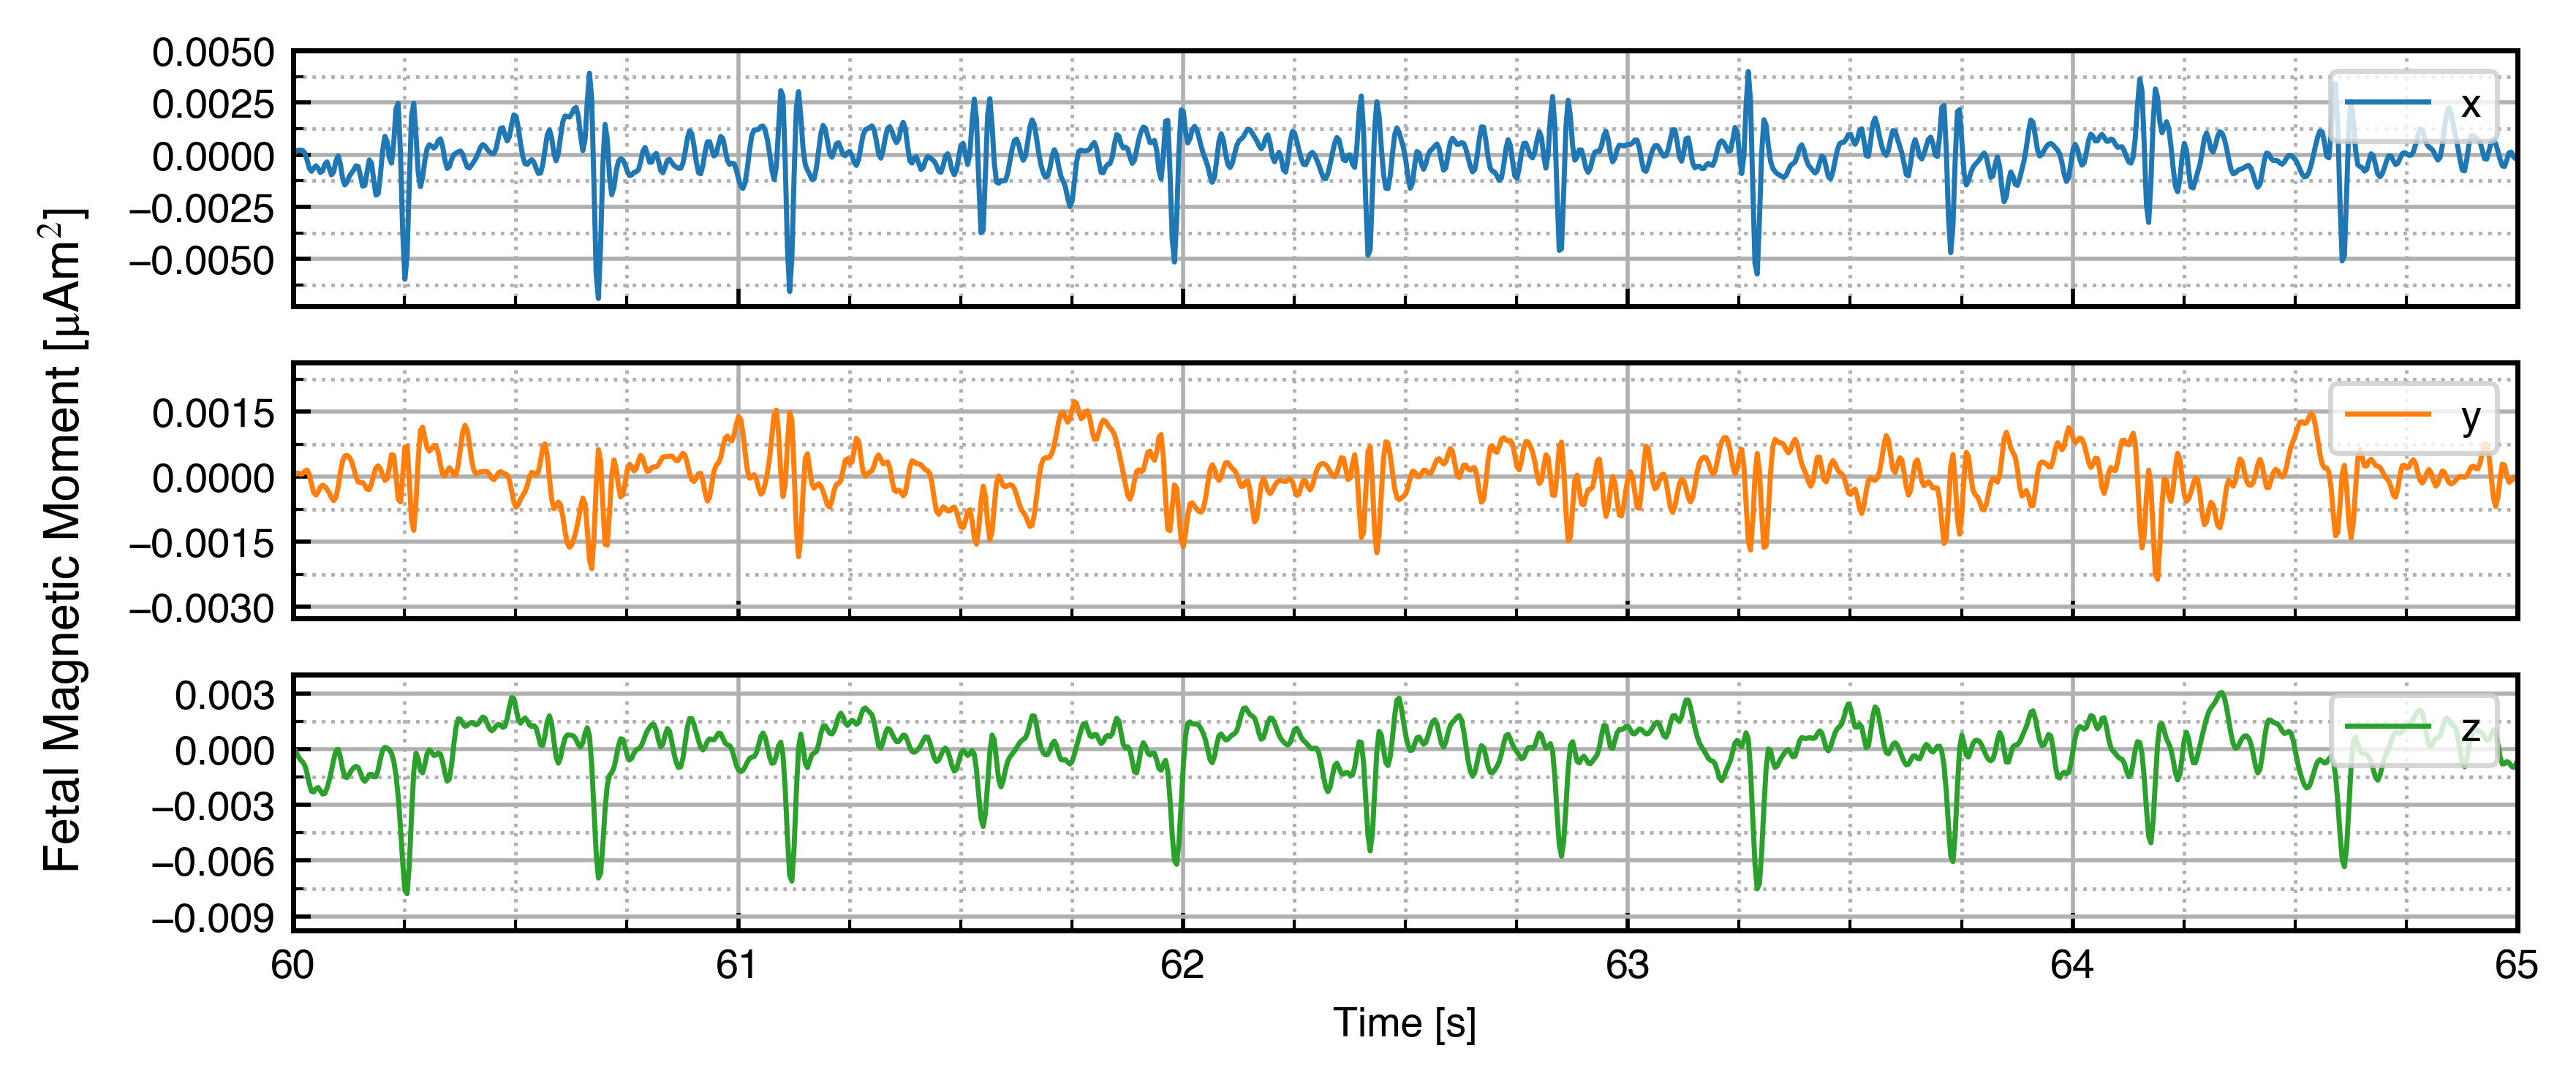

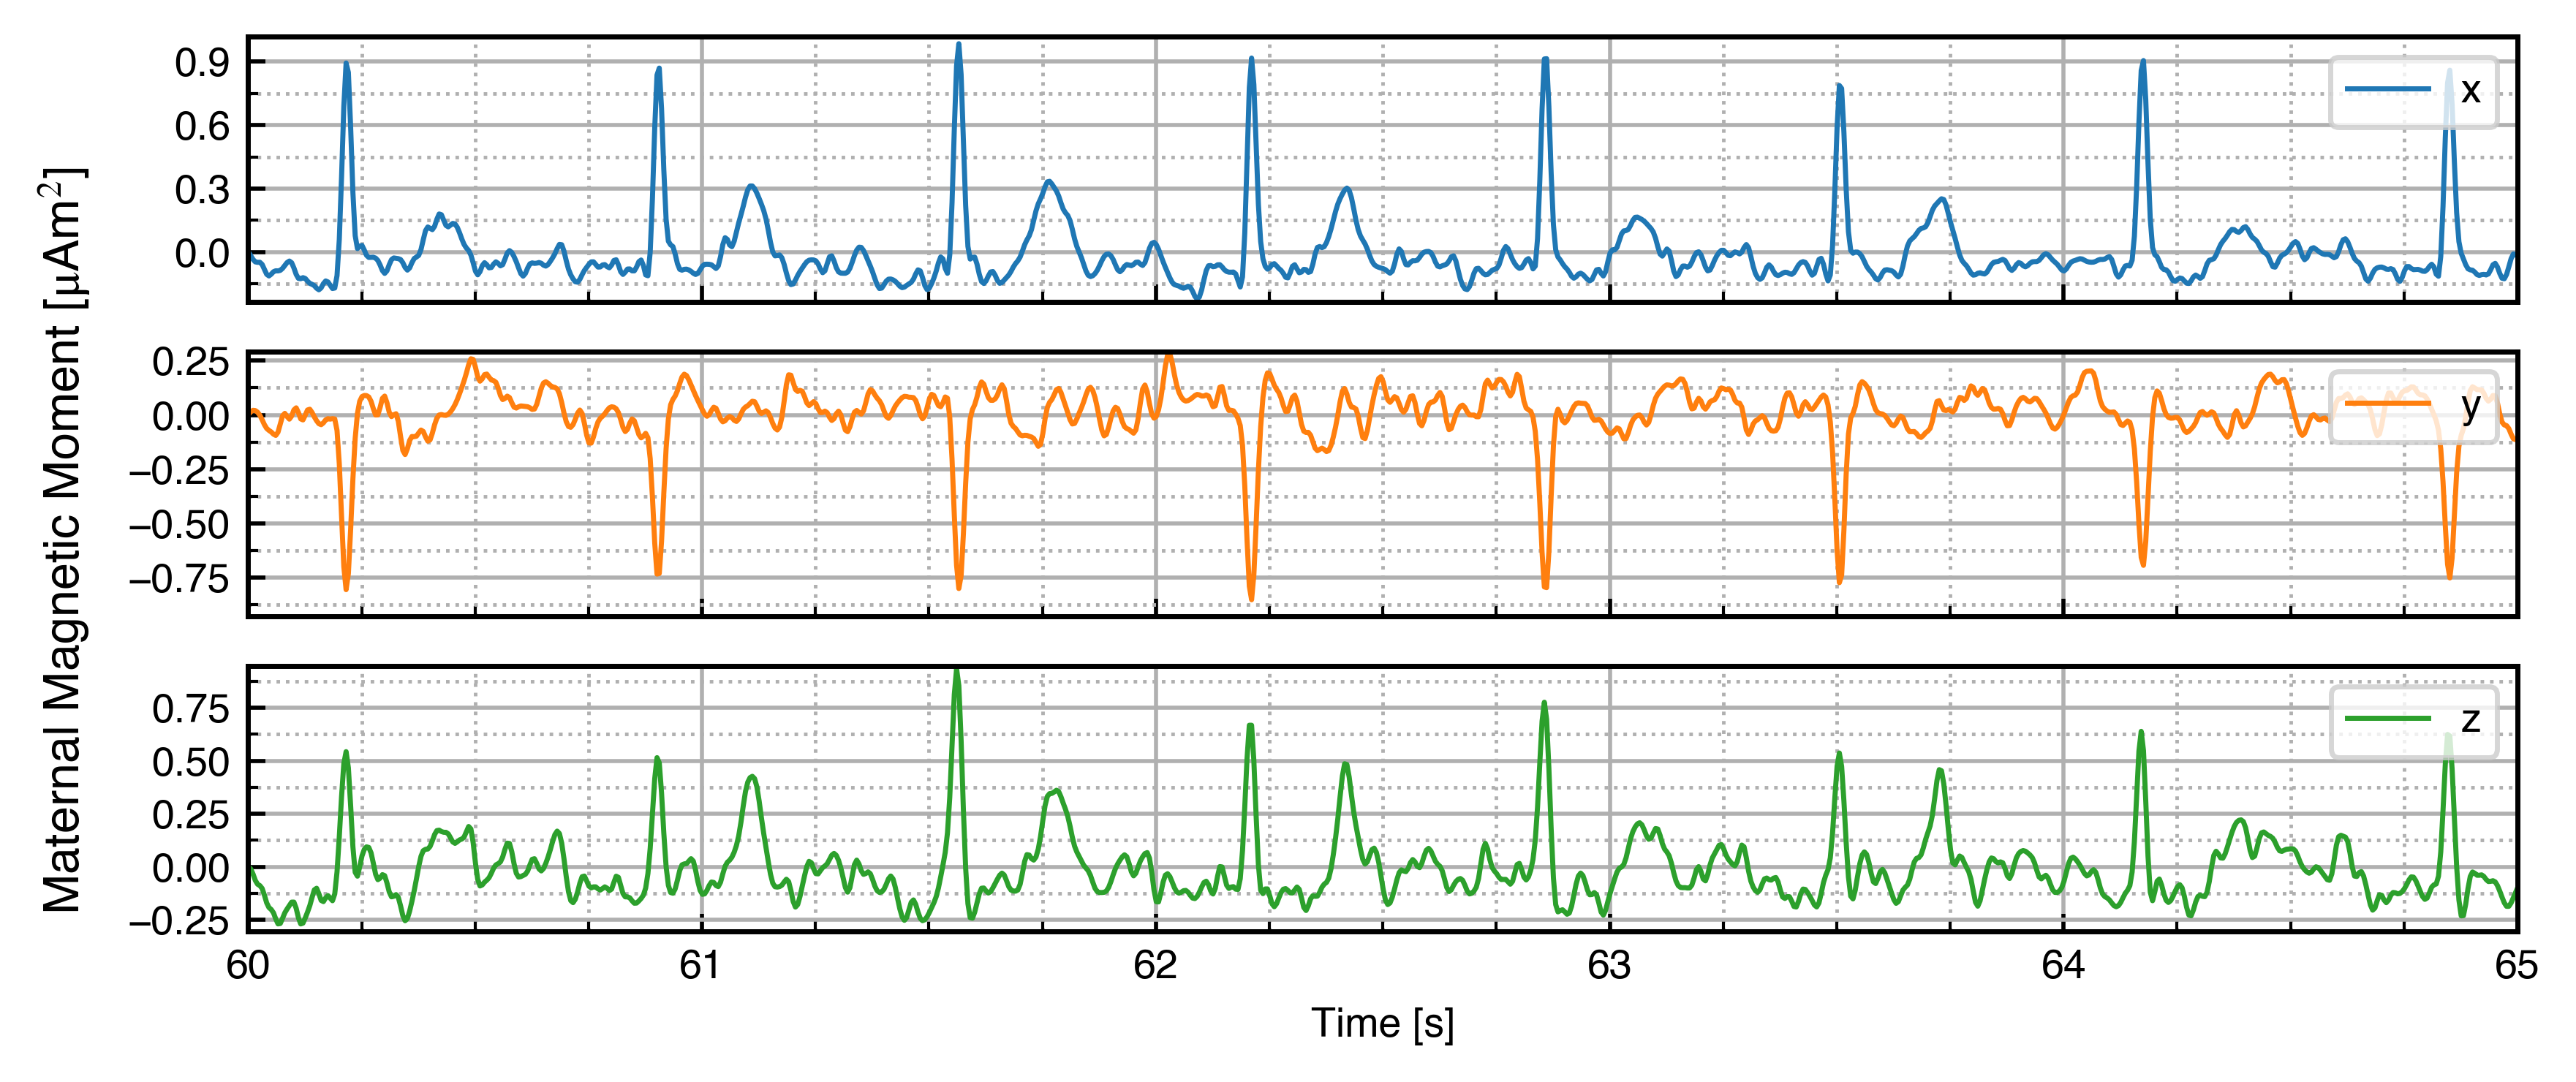

In [8]:
from fmcg.utils.plotting.plot_utils import plot_magnetic_moments_separate_axes

# plot reconstrcted moments
plot_magnetic_moments(
    m_hat,
    time=time_window,
    xlim=[60, 65],
    preprocess_method="biosppy",
) 

# plot moments on separate axes for better visibility
plot_magnetic_moments_separate_axes(
    m_hat,
    time=time_window,
    xlim=[60, 65],
    preprocess=True,
    preprocess_method="biosppy",
    separate_figures=True,
    #savename="/data/plots/P071_S01_R001_moments_separate.pdf"
) 

/jonas/fmcg/fmcg/utils/plotting/plot_utils.py:1380: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r_fitted_cm[i, 0], r_fitted_cm[i, 2], r_fitted_cm[i, 1],
/jonas/fmcg/fmcg/utils/plotting/plot_utils.py:1403: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


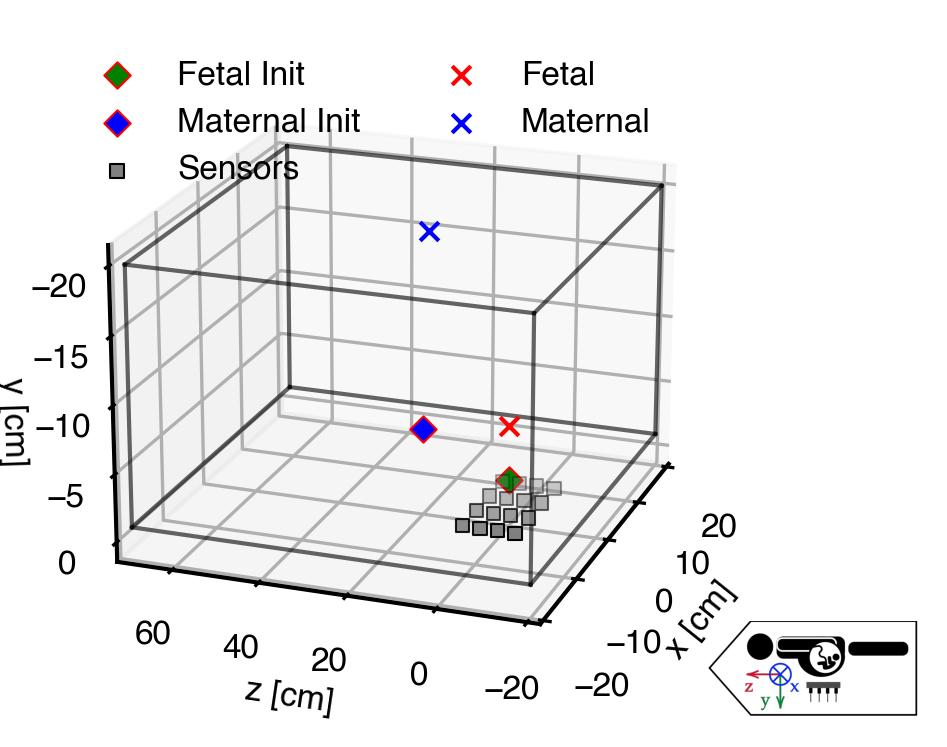


Fetal dipole: (-0.017, -0.066, -0.011) m
Maternal dipole: (0.044, -0.186, 0.223) m


In [9]:
# Plot fitted dipole positions in 3D using matplotlib
from fmcg.utils.plotting.plot_utils import plot_dipole_positions_3d

# Define bounds box (fetal and maternal)
BOX_BOUNDS = np.array([
    [(-0.2, 0.2), (-0.2, -0.01), (-0.2, 0.2)],   # Fetal bounds
    [(-0.4, 0.4), (-0.4, -0.01), (0.2, 0.7)]      # Maternal bounds
]) * 100  # Convert to cm

# Use the utility function for plotting
plot_dipole_positions_3d(
    r_fitted=r_hat,
    r_sensors=r_sensors,
    r_init=r_init,
    bounds=BOX_BOUNDS,
    coord_img_bbox=[0.8, .0, 0.20, 0.20],
    time_idx=0,
    dpi=300,
    colors=['red', 'blue'],
    labels=['Fetal', 'Maternal'],
    show_coord_img=True
)

# Print fitted positions
r_fitted = r_hat[0]
print(f"\nFetal dipole: ({r_fitted[0, 0]:.3f}, {r_fitted[0, 1]:.3f}, {r_fitted[0, 2]:.3f}) m")
print(f"Maternal dipole: ({r_fitted[1, 0]:.3f}, {r_fitted[1, 1]:.3f}, {r_fitted[1, 2]:.3f}) m")

# Post Processing - Heartbeat Averaging

/jonas/fmcg/fmcg/analysis/heartbeat_averaging.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


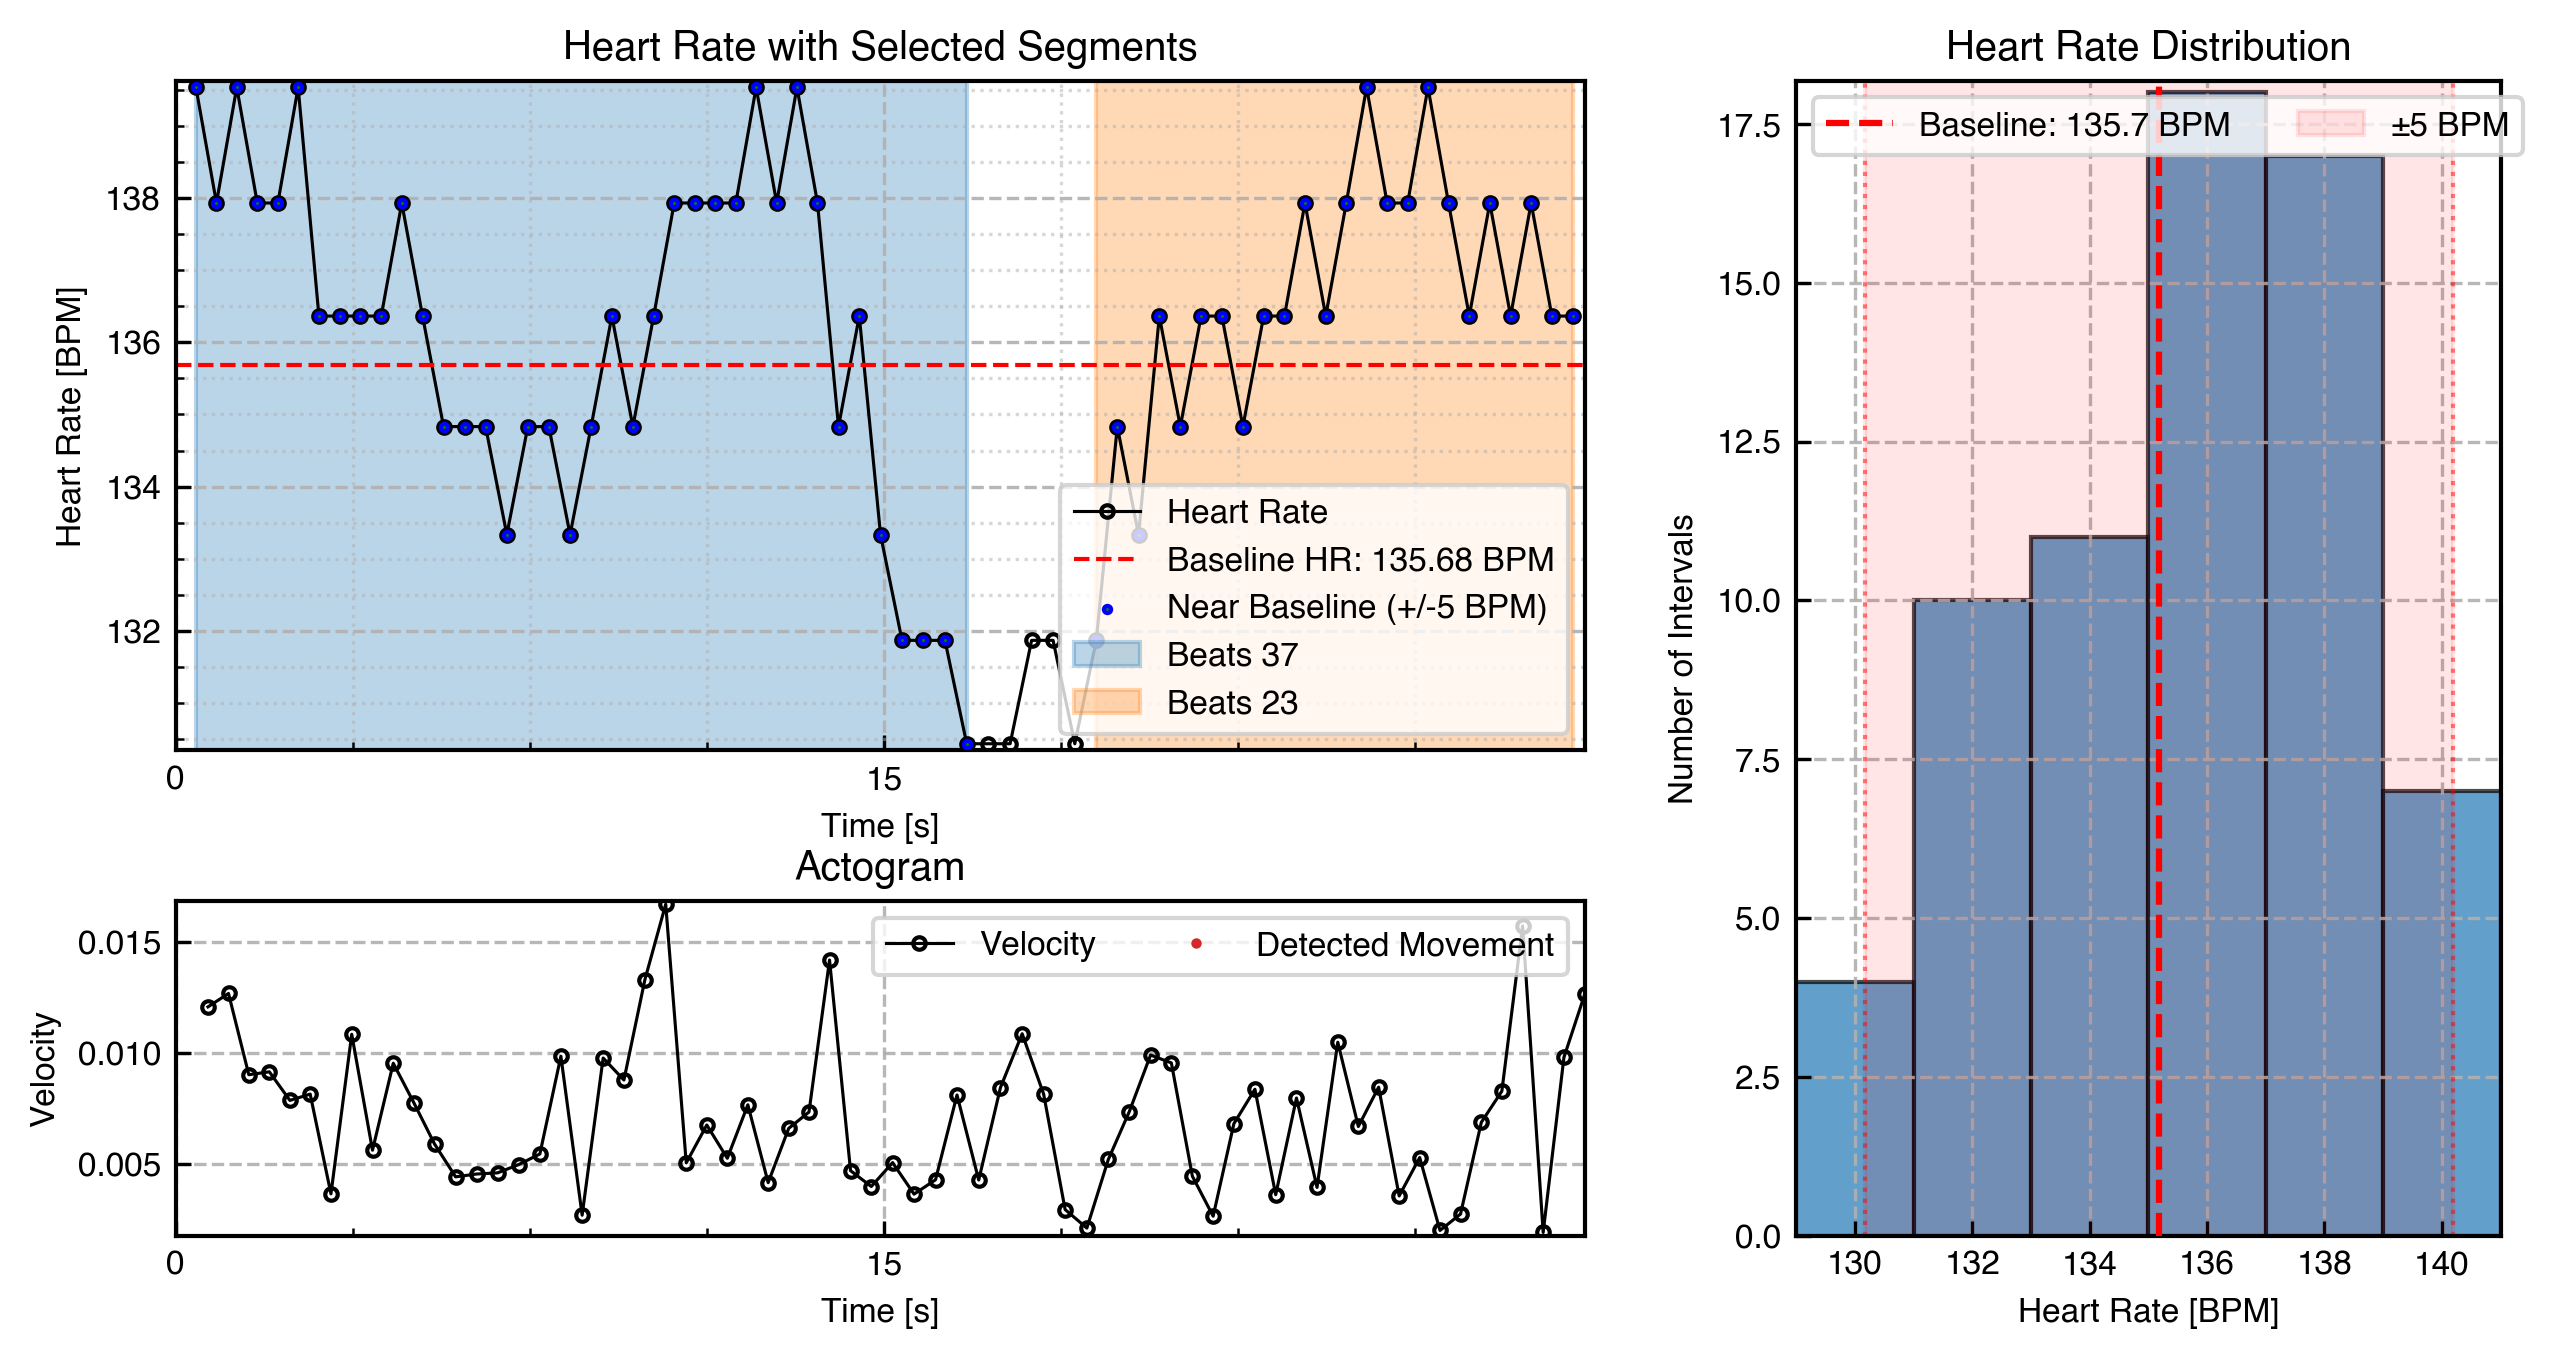

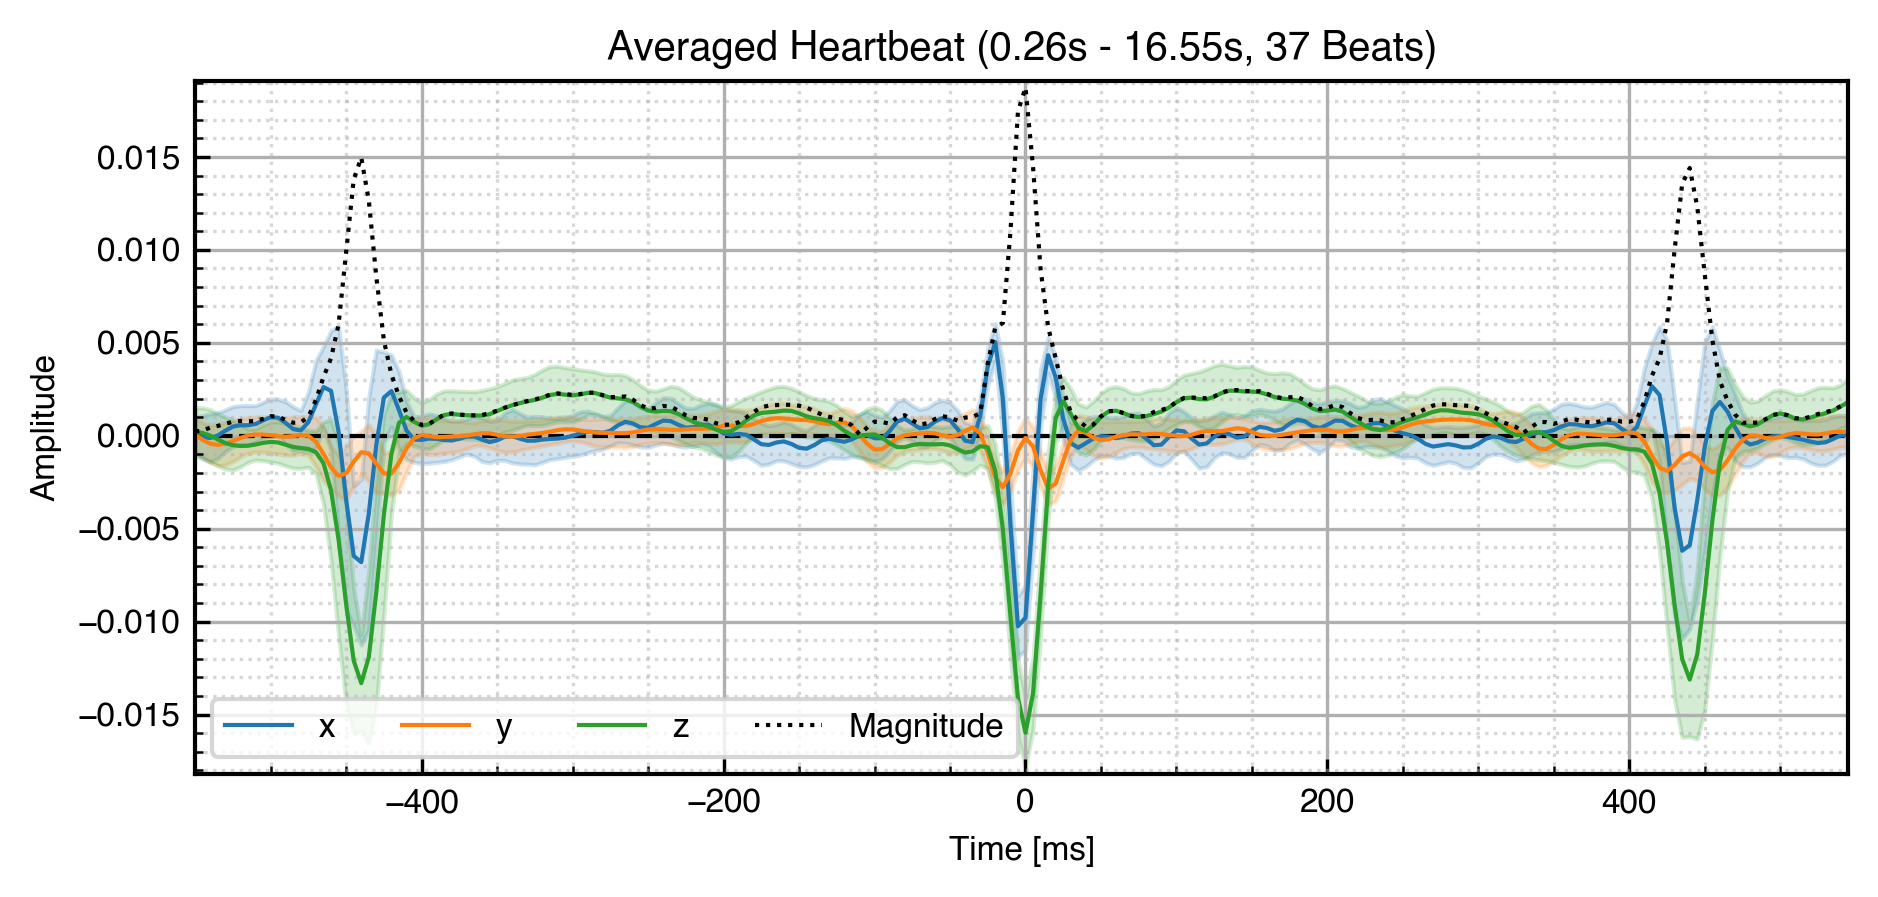

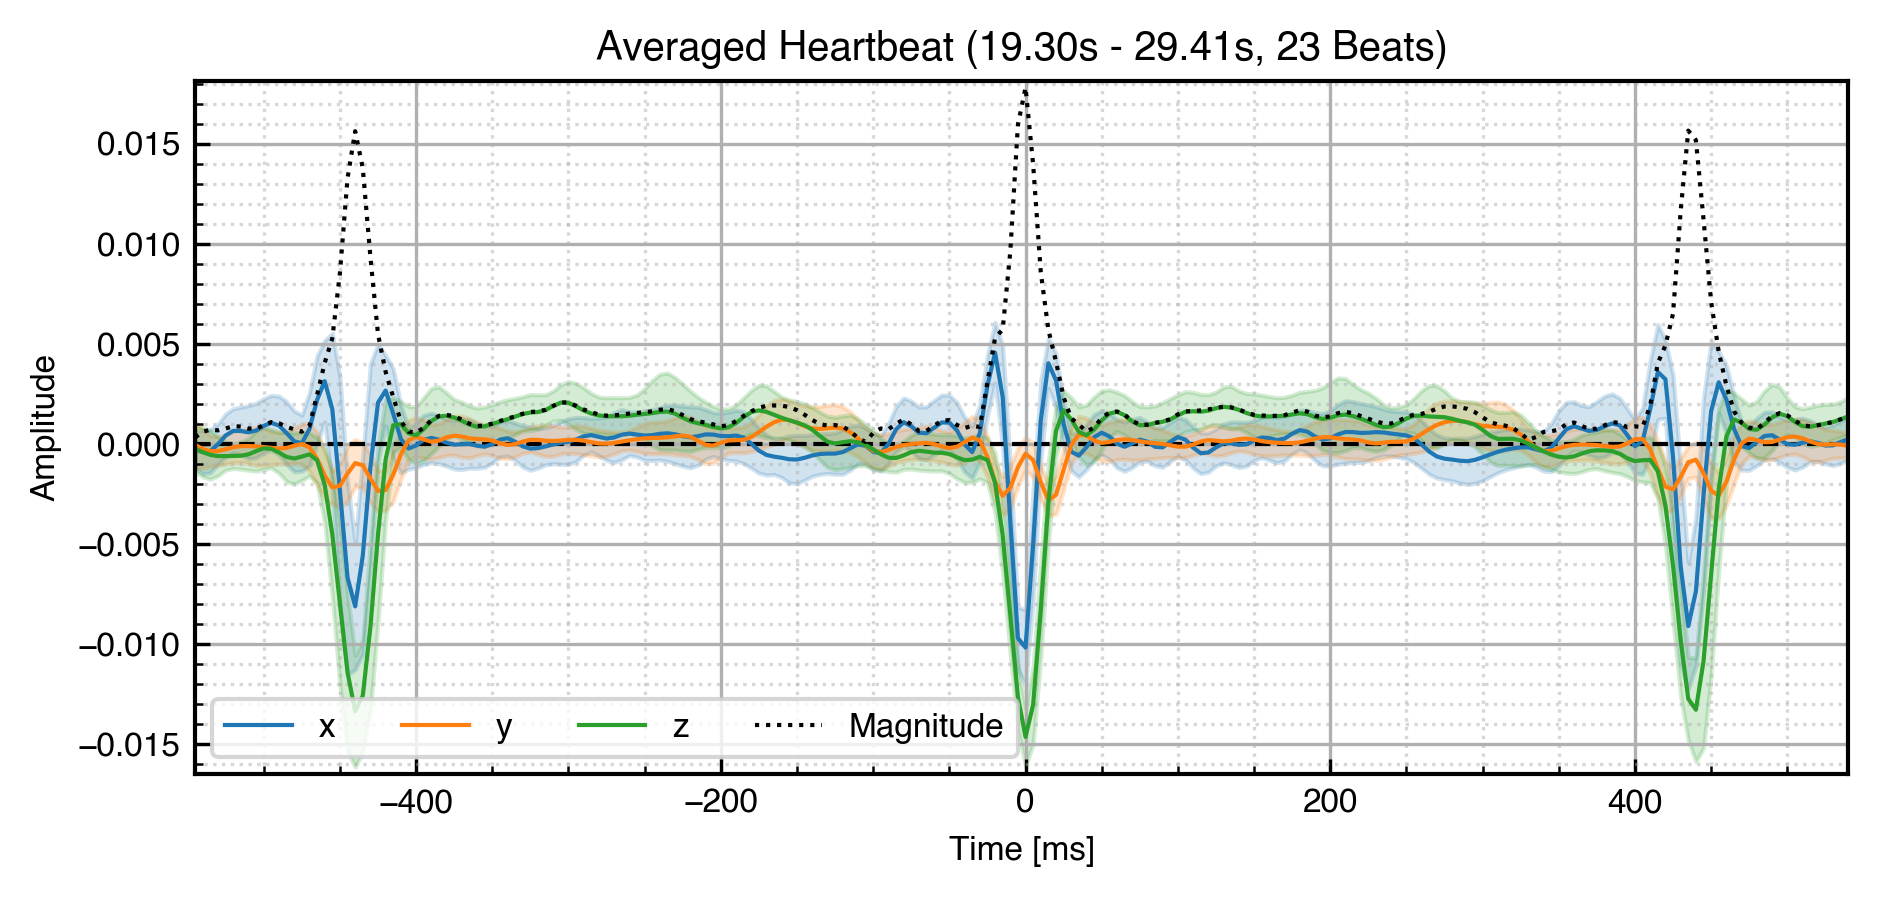

In [27]:
# fetal heart rate estimation and heartbeat averaging
heartRate, peaks = compute_hr(m_hat[:,0], fs, plot=False)
avgs, segments = find_segments_and_average_heartbeats(peaks, m_hat[:,0], fs)

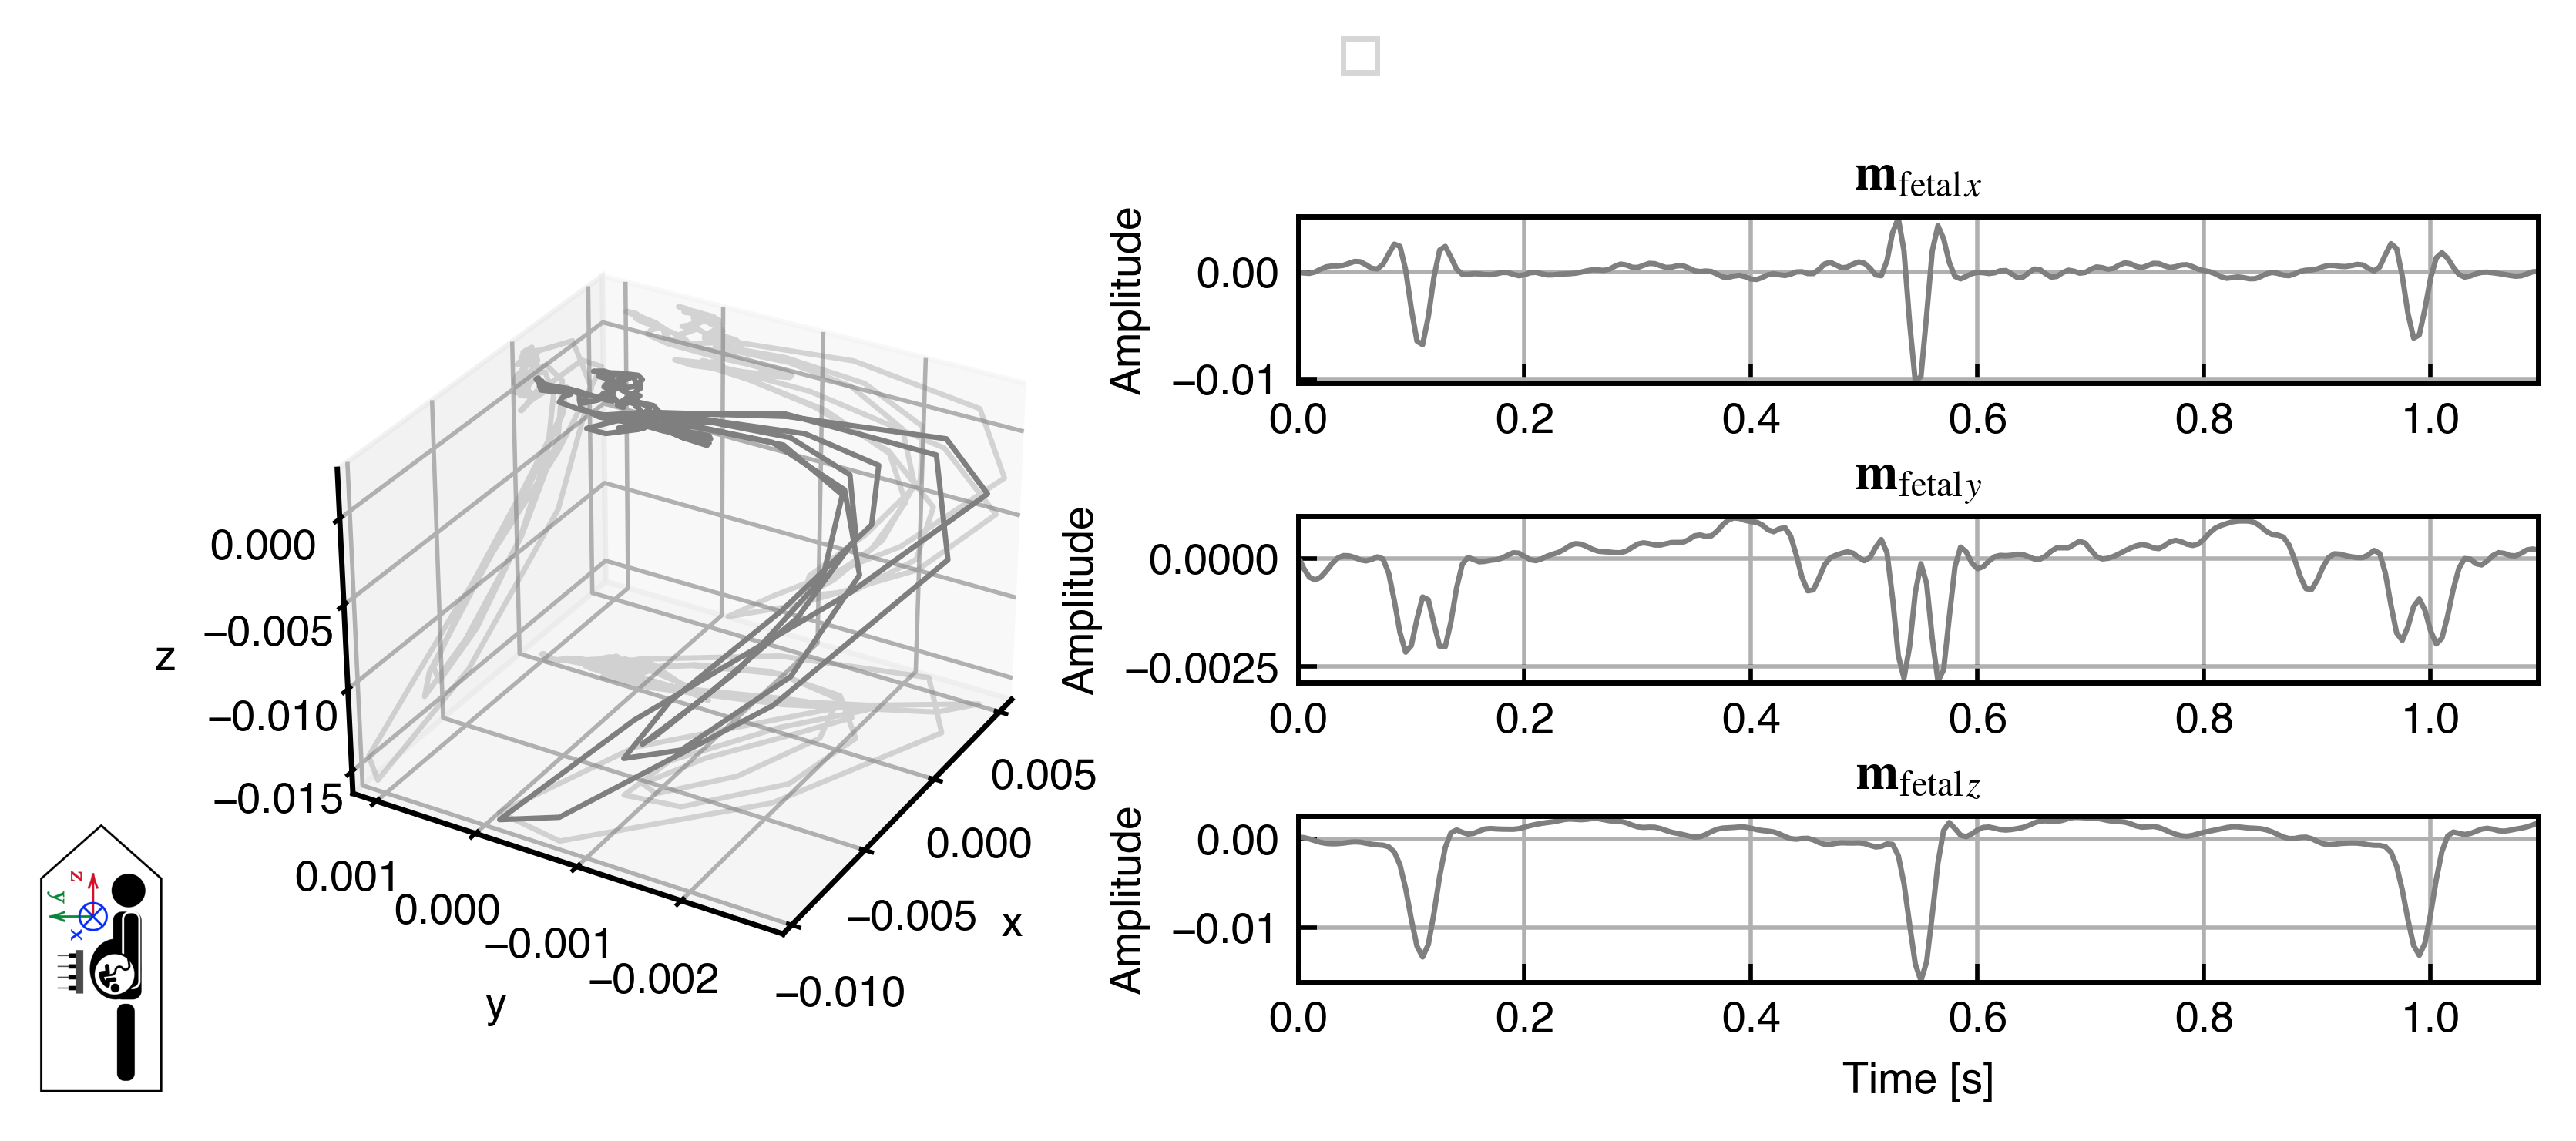

In [39]:
from fmcg.utils.plotting.plot_utils import plot_vcg

beat_mean, beat_std, beat_t = avgs[0]
plot_vcg(beat_mean, None,fs=fs, sig_name=r"$\mathbf{m}_\text{fetal}$")

# Using the Pipeline API

For a complete end-to-end workflow, use the `Pipeline` class which handles:
- Configuration management via dataclasses
- Automatic preprocessing
- Solver initialization and optimization
- Post-processing and heartbeat detection
- Resource management (GPU cleanup, etc.)

Example:

In [11]:
from fmcg import Pipeline, PipelineConfig, SolverConfig, DataConfig, PreprocessingConfig

r_bnds = np.array([
    [(-0.3, 0.3), (-0.3, -0.005), (-0.3, 0.3)],
    [(-0.3, 0.3), (-0.3, -0.005), (0.1, 0.6)]
])

r_init = r_init = np.array([[[0, -0.02, 0.0], [0, -0.05, 0.2]]])

# Create configuration
config = PipelineConfig(
    preprocessing=PreprocessingConfig(
        whitening="PCA",
        rescale_whitening=False,
        process_segments=False,
        min_segment_length=1,
        detect_artifacts=False,
    ),
    data=DataConfig(
        ds_path=DS_PATH,
        patient="P097",
        series="S07",
        sig_group_names="R001",
        noise_group_names="R004",
        sampfrom=30,
        sampto=60,
    ),
    solver=SolverConfig(
        num_dipoles=2,
        optimizer="lamb",
        r_bnds=r_bnds,
        r_init=r_init,
    ),
    device="cuda:0",
)

# Use pipeline with context manager for automatic cleanup
with Pipeline() as pipeline:
    results = pipeline.run(config)
    print("Pipeline ready to run!")
    print("See the Pipeline documentation for complete usage.")

Iterations: 100%|██████████| 800/800 [00:12<00:00, 62.05it/s, Best Loss=0.0843]


Pipeline ready to run!
See the Pipeline documentation for complete usage.


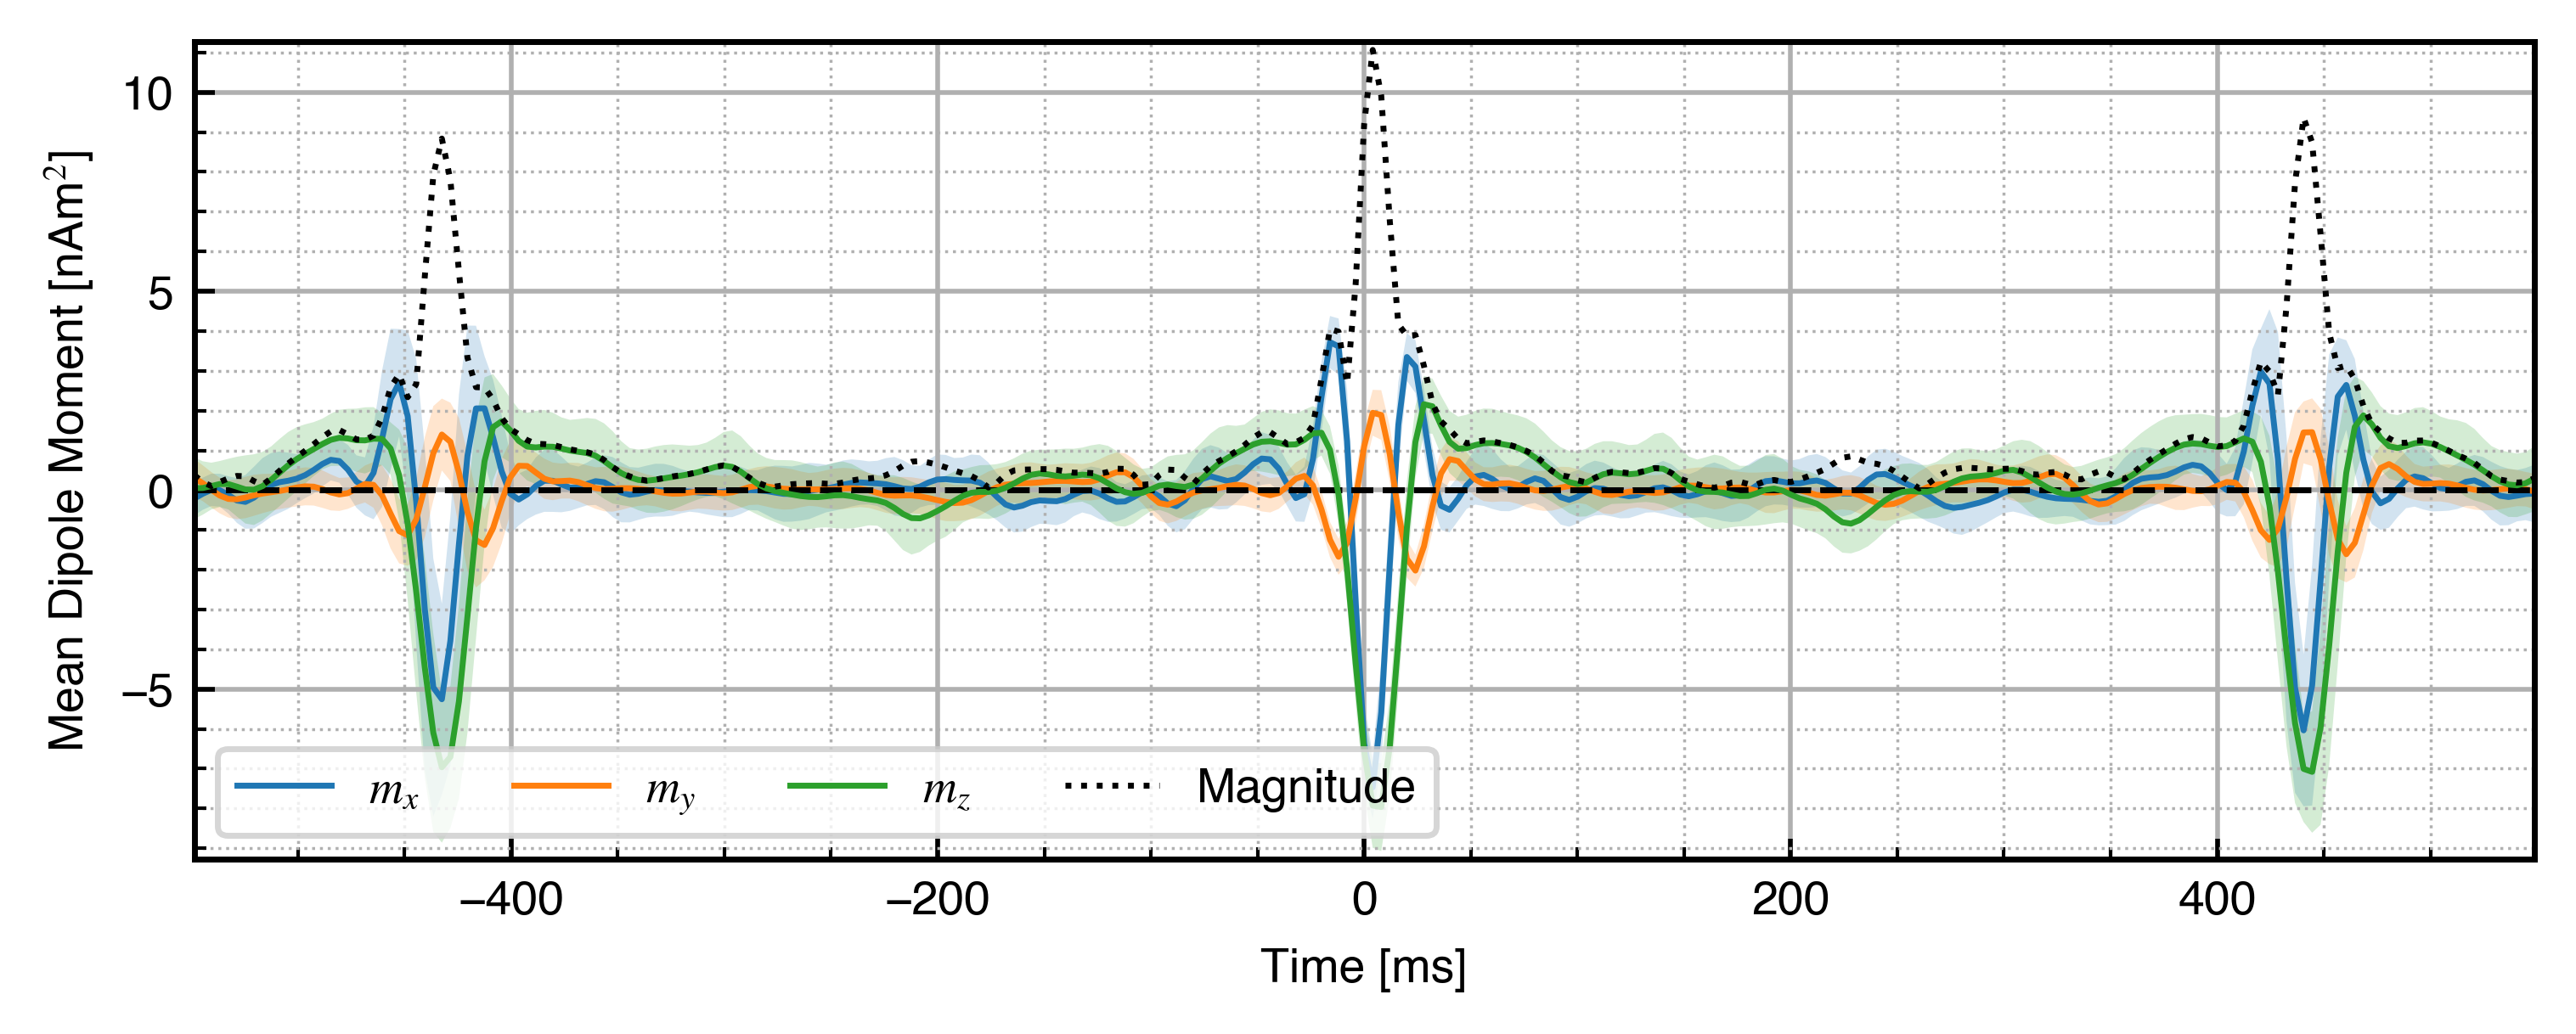

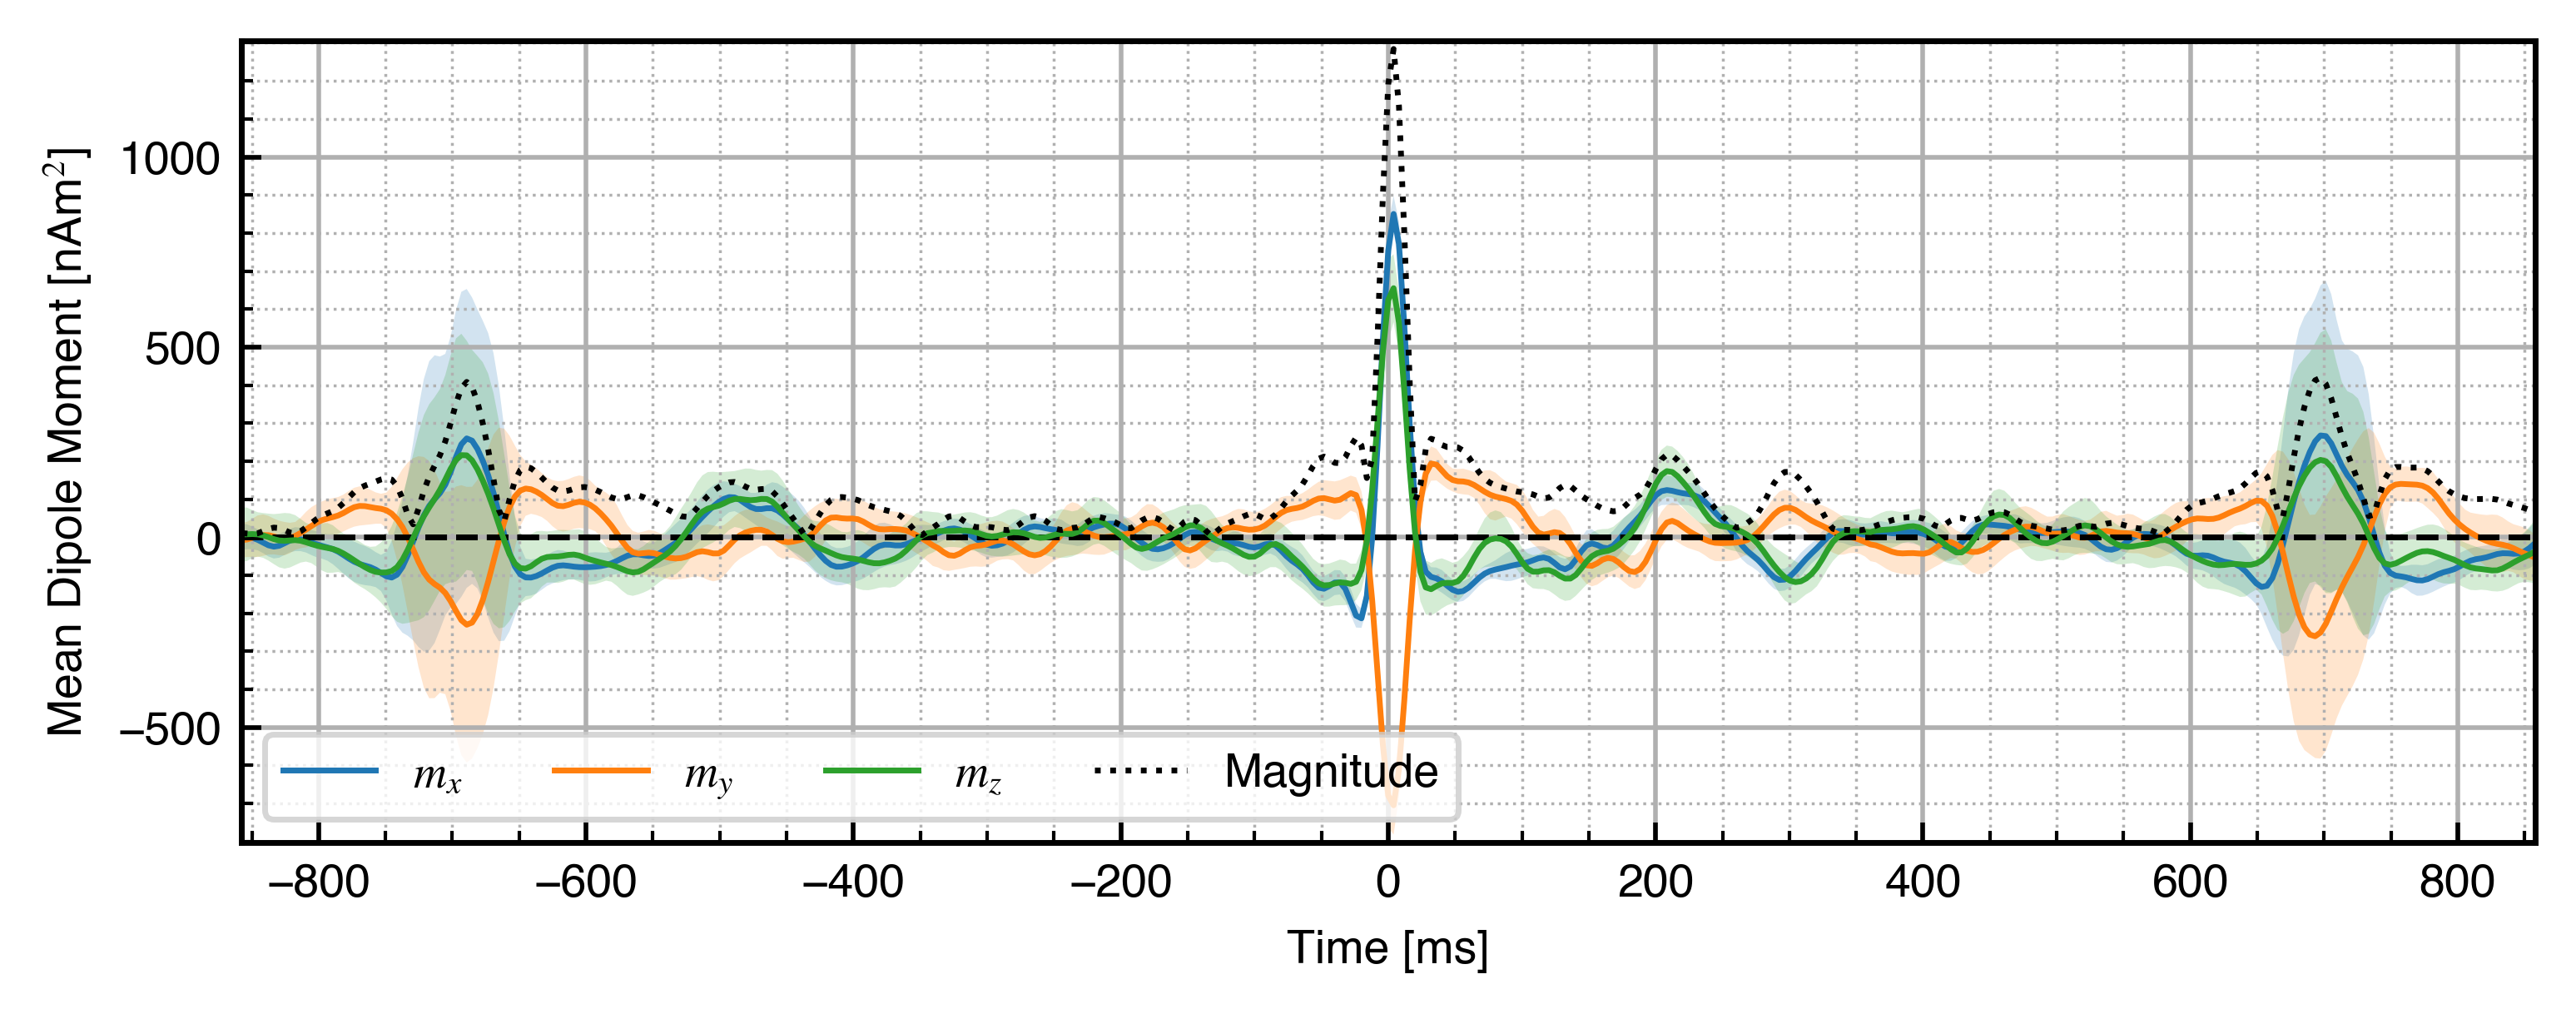

In [12]:
from fmcg.analysis.heartbeats import plot_averaged_beats

plot_averaged_beats(
    pipeline.heartbeats_dict
)